In [3]:
# Import the required libraries
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [7]:
# Read the CSV file 
df = pd.read_csv("lfw_arnie_nonarnie.csv")

In [8]:
# Exploratory analysis

print(df.describe())
print(df.info())

print(df['Label'].value_counts()) # the targat column is imbalanced

                  0             1             2             3             4  \
count  1.900000e+02  1.900000e+02  1.900000e+02  1.900000e+02  1.900000e+02   
mean   3.626611e-07 -1.567368e-07  8.608947e-08  2.308705e-07 -6.139842e-08   
std    4.174661e+00  2.793032e+00  2.280145e+00  2.186781e+00  1.623655e+00   
min   -1.035394e+01 -7.227386e+00 -5.509459e+00 -5.586218e+00 -3.893015e+00   
25%   -3.168281e+00 -1.793691e+00 -1.425456e+00 -1.251774e+00 -1.207175e+00   
50%   -1.566209e-01  7.839222e-02 -1.296116e-01 -3.981813e-02 -2.011608e-02   
75%    2.568815e+00  1.664303e+00  1.483138e+00  1.419419e+00  1.100513e+00   
max    1.182195e+01  7.844313e+00  6.406050e+00  6.569901e+00  5.274433e+00   

                  5             6             7             8             9  \
count  1.900000e+02  1.900000e+02  1.900000e+02  1.900000e+02  1.900000e+02   
mean   7.773526e-08 -1.379737e-07 -1.238158e-07 -3.516316e-08 -1.758368e-07   
std    1.464663e+00  1.331932e+00  1.209180e+00  1.

In [9]:
# Missing values check
print(df.isna().sum().sort_values(ascending = False)) # No missing values 

0        0
95       0
97       0
98       0
99       0
        ..
51       0
52       0
53       0
54       0
Label    0
Length: 151, dtype: int64


In [11]:
# Seperate the predictor and class label
X = df.drop('Label', axis=1)
y = df['Label'] 

# Split the data into training and testing sets using stratify to balance the class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [16]:
SEED = 42

# Decided to use 3 classifier models that don't rely on liner relationship
models = {"knn": KNeighborsClassifier(), 
          "Random forest": RandomForestClassifier(class_weight='balanced', random_state= SEED),
          "Logistic regression": LogisticRegression(class_weight='balanced', random_state= SEED)}

# Hyper parameters tuning

param_grid_knn = {'model__n_neighbors': [3, 5, 7, 9],
                  'model__weights': ['uniform', 'distance'],
                  'model__metric': ['euclidean', 'manhattan']
                 }


param_grid_rf = {'model__n_estimators': [50, 100, 200],
                 'model__max_depth': [None, 10, 20, 30],
                 'model__min_samples_split': [2, 5, 10],
                 'model__min_samples_leaf': [1, 2, 4]
                }

param_grid_logreg = {'model__penalty':['l2','none'],
                     'model__C': [0.01,0.1, 1, 10],
                     'model__solver': ['newton-cg', 'lbfgs']
                    }


# Dictionary of hyperparameters for GridSearchCV
param_grids = {'knn': param_grid_knn,
               'Random forest': param_grid_rf,
               'Logistic regression': param_grid_logreg
              }

results = []

# Checking each model and the best hyper parameters
for model_name,model in models.items():
    kf = KFold(n_splits = 5, random_state= SEED, shuffle= True)
    model_pipeline = Pipeline([('scaler', StandardScaler()),
                                  ('model', model)])
    
    grid_search = GridSearchCV(model_pipeline, 
                               param_grids[model_name], 
                               cv=kf, 
                               n_jobs=-1, 
                               scoring= 'accuracy')
    
    g = grid_search.fit(X_train,y_train)
    test_score = g.score(X_test,y_test)
    results.append((model_name, grid_search.best_params_, test_score))

# Store the results in a dataframe   
results_df = pd.DataFrame(results, columns = ['Model', 'Best Parameters', 'Test Score'])
results_df = results_df.sort_values('Test Score', ascending = False)





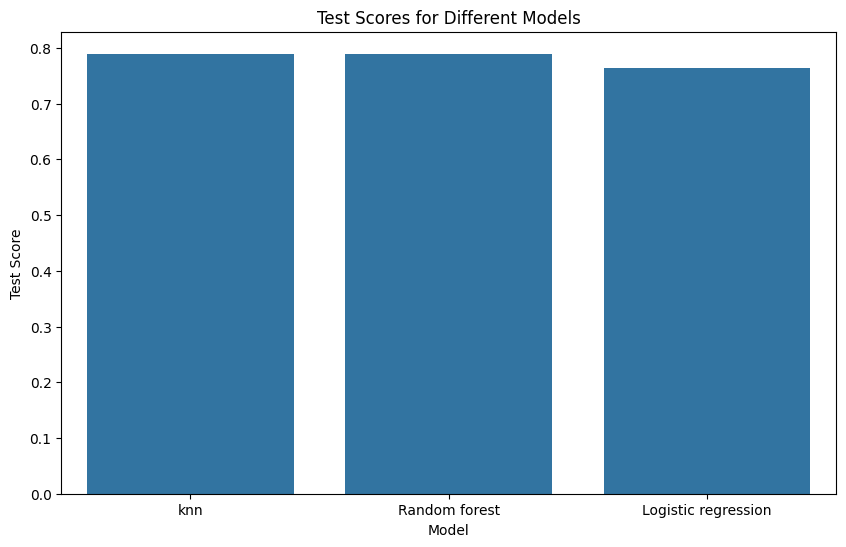

In [17]:
# Present the score per model
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test Score', data=results_df)
plt.title('Test Scores for Different Models')
plt.xlabel('Model')
plt.ylabel('Test Score')
plt.show()

In [37]:
# Store and print the best model, parameters and score
best_model_name = results_df.iloc[0,0]
best_model_info = results_df.iloc[0,1]
best_model_cv_score = results_df.iloc[0,2]
print(f"The best model is {best_model_name} with the parameters {best_model_info} and the score {best_model_cv_score}")

The best model is knn with the parameters {'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'uniform'} and the score 0.7894736842105263


In [30]:
# Call the model with the best parameters on the data
knn1 = KNeighborsClassifier(metric=best_model_info['model__metric'],
                            n_neighbors = best_model_info['model__n_neighbors'], 
                            weights= best_model_info['model__weights'])

knn1.fit(X_train,y_train)
y_pred = knn1.predict(X_test)

In [32]:
# Evaluate the model's performance
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

[[29  1]
 [ 6  2]]
Accuracy: 0.8158
Precision: 0.6667
Recall: 0.2500
F1 Score: 0.3636
